In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import curve_fit
import sys
import os
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../../..'))

from source.include.components import *
from source.include.circuits import *
from source.include.helpers import *
from source.include.demod import *

from resonator_fitting.include import circle_fitting as cf
from resonator_fitting.include import resonance_fitting as rf
from resonator_fitting.include import all_resonances as ar


In [37]:
loaded_data = np.loadtxt('data/NIST_full_s21.txt', dtype=complex)
freqs_loaded = np.real(loaded_data[:, 0])
s21_loaded = loaded_data[:, 1]
s21_db_loaded = np.abs(s21_loaded) 
s21_phase = np.angle(s21_loaded)
s21_logMag = 20*np.log10(s21_db_loaded)
s21_logMag = s21_logMag-np.max(s21_logMag)
data = np.load('data/flux_response_params.npz')
ibias = data['ibias']
I0fits = data['I0fits']
Minfits = data['Minfits']
Mcfits = data['Mcfits']
fbfits = data['fbfits']
lambfits = data['lambfits']
meas_flux = np.load('data/measured_flux_response.npz')
ibias = meas_flux['ibias']
dfs = meas_flux['freqs']
circle_params = np.loadtxt('data/NIST_full_params.txt', dtype=float)

VNA = VNA_Simulator(z0=50)

squids = []
channels = []
num_channels = 32

for i in range(num_channels):
    squid_ch = SQUID(L_j=70e-12, L_s=24.2e-12, lamb=None, phi_ext=0.0) 
    squid_ch.add_flux_line("FluxRamp", M=15e-12, initial_current=0.0)
    squid_ch.add_flux_line("TrappedFlux", M=15e-12, initial_current=0.0)
    squid_ch.add_flux_line("Input", M=246e-12)   
    
    ind_ch = Inductor(49.1e-12)
    tuned_L_ch = ScreenedInductor(primary_inductor=ind_ch, screening_device=squid_ch, M=3.4e-12)
    squids.append(squid_ch)


    circ_fit = np.copy(circle_params[i]) 
    circ_fit[2] = circ_fit[2] + fbfits[i] 

    
    length, Cc_val, Qi_val = extract_physical_params(circ_fit, tuned_L_ch, Cc_in=9.4e-15)

    squid_ch.set_current("TrappedFlux", I0fits[i])

    cap_ch = Capacitor(C=Cc_val)
    phys_res = Resonator(length=length, load=tuned_L_ch, v_p=1.15e8, Qi=Qi_val)

    channel = Channel(name=f"Ch{i+1}") 
    channel.add(cap_ch)
    channel.add(phys_res)
    channel.add(squid_ch)
    channels.append(channel)
    VNA.add(channel, 'shunt')

VNA.draw_schematic(use_color=True, max_draw=1)
freqs = np.linspace(np.min(freqs_loaded),np.max(freqs_loaded),2000)
S = VNA.get_s_matrix(freqs)
S_baseline = VNA.get_s_matrix(freqs_loaded)
baseline_peaks_idx = find_all_peaks(freqs_loaded, S_baseline[1, 0])
baseline_frs = freqs_loaded[baseline_peaks_idx]
plt.figure(figsize=(12,6))
plt.plot(freqs_loaded*1e-9, s21_logMag,markersize = 0.5, color = 'b',label = "Measured S21 for NIST uMux", linewidth = 2)
plt.plot(freqs*1e-9, 20*np.log10(S[1,0]), color = 'r', label = "Simulated S21")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Log Mag (dB)")
plt.title("Measured NIST Multiplexer Spectrum", fontsize = 16)
plt.legend()
plt.show()


IndexError: index 3 is out of bounds for axis 0 with size 3

### Now I want to simulate the tone tracking that Morgan is building.

This takes in the measured flux response curves and the flux ramp and outputs 32 GHz tones that change frequency over time. I then apply the flux ramp, and the tones should each sit at the bottom of the resonators. Now a pulse will shift the resonator, but the tone will remain stationary, so by measuring the phase shift of the S21 at the GHz tones compared to the input tones, we should see pulses. 

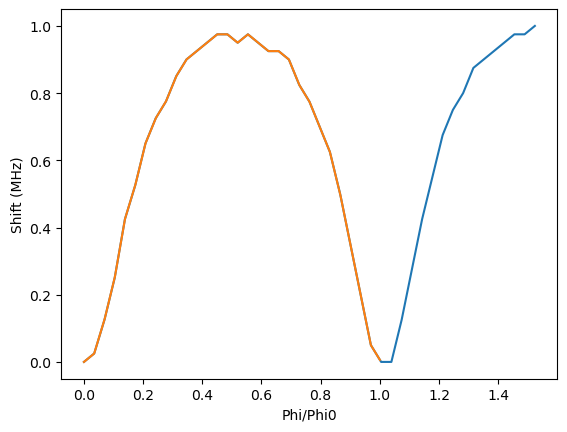

In [35]:

# Create the exact 1024 points you want to sample (from 0 to 1 period)
phi_points = np.linspace(0, 1, 1024) * Phi0
luts = []
flux_points_array = []

for i in range(len(dfs)):
    # Your true x-axis for this specific frequency array
    flux_points = ibias * Minfits[i]
    flux_points_array.append(flux_points)
    
    # Interpolate: 
    # Evaluate at 'phi_points', using 'flux_points' as the known x-coordinates 
    # and 'dfs[i]' as the known y-coordinates.
    lut_entry = np.interp(phi_points, flux_points, dfs[i])
    
    luts.append(lut_entry)

lut = np.array(luts)
flux_points_array = np.array(flux_points_array)

    
for i in range(1):
    plt.plot(flux_points_array[i]/Phi0, dfs[i]*1e-6)
    plt.plot(phi_points/Phi0, luts[i]*1e-6)
    plt.xlabel("Phi/Phi0")
    plt.ylabel("Shift (MHz)")

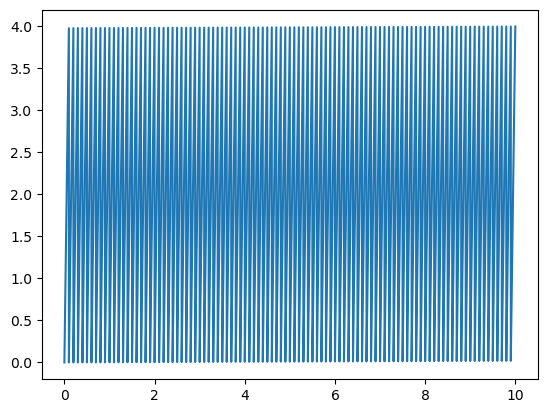

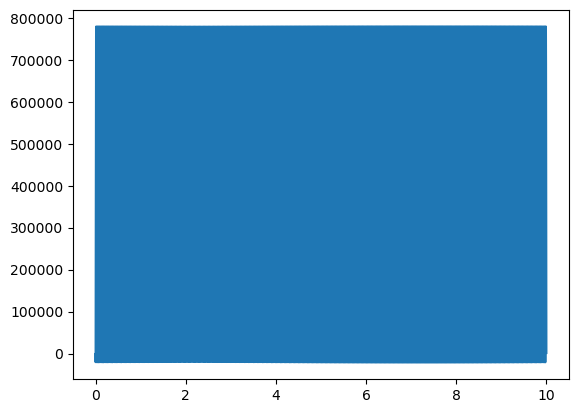

In [12]:
time_steps = np.linspace(0,10e-3,20000)
f_ramp = 10e3 
nPhi0 = 4
f_mod = nPhi0 * f_ramp

flux_ramp = Flux_Ramp(nPhi0=nPhi0, freq=f_ramp, time_array=time_steps)
flux_array = flux_ramp.phi_ramp
plt.plot(time_steps*1e3, flux_array/Phi0)
plt.show()
frs = []

for c_idx in range(len(channels)):

    guess = baseline_frs[c_idx]
    channel = channels[c_idx]
    channels[c_idx].squids[0].flux_lines["FluxRamp"].set_flux(flux_array)
    fr_curve = channel.get_resonance(f_guess=guess)
    frs.append(fr_curve)
 
plt.plot(time_steps*1e3,frs[0]-baseline_frs[0])


    

